In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
library(readr)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching packa

In [2]:
mica_df <- read_csv("../../data/mica_df_with_pcs.csv")
lucas_df <- read_csv("../../data/lucas_df_w_pc_gemini2.csv")
val_df <- read_csv("../../data/val_df_with_pcs.csv")

mica_df <- mica_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

lucas_df <- lucas_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

mica_df_filtered <- mica_df[mica_df$`Coded Type` %in% c("Lung (LU)", "No cancer (NC)"), ]

Rows: 540 Columns: 1304
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (73): id, Stage, Coded Type, type, Delfi ID (Aliquot 2), DL ID, DL Suf...
dbl (1225): clinical_CCI, clinical_age, Smoking, ratio_1, ratio_2, ratio_3, ...
lgl    (6): Match?, Rack (plasma), Rack (cfDNA), check, Robot Protocol, Repl...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 287 Columns: 959
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (851): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): 

In [3]:
batch <- read_csv("../../data/LUCAS_batching.csv")

Rows: 419 Columns: 2
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): id
dbl (1): library_batch

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
lucas_df <- inner_join(lucas_df, batch, by="id")

In [5]:
model_seq <- readRDS("../../data/mathios_architecture_seq.rds")

# Clinical Variables

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



Attaching package: ‘ComplexHeatmap’


The following object is masked from ‘package:recipes’:

    prepare


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.

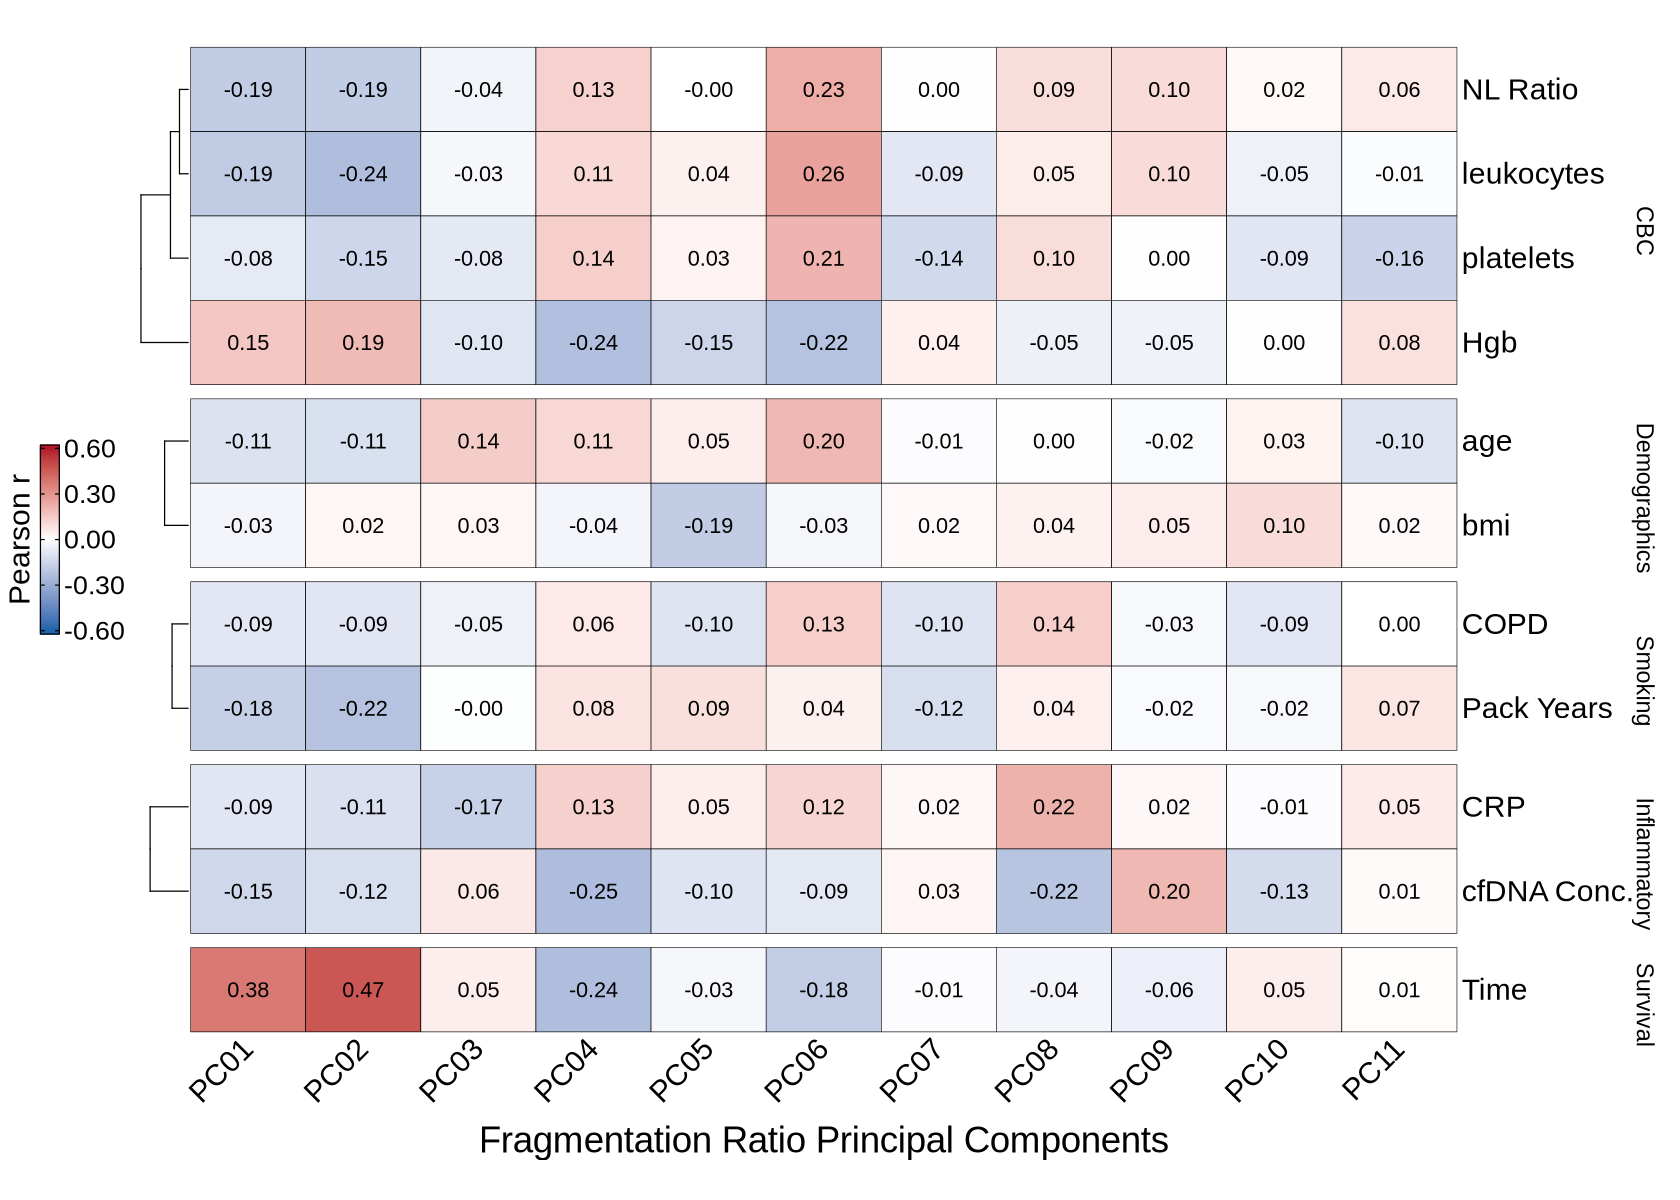

In [6]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(tidyr)

# Define clinical variables
clinical_vars <- c(
  "clinical_leukocytes", "clinical_nlratio",
  "clinical_Hgb", "clinical_platelets",
  "clinical_age", "clinical_sex", "clinical_bmi",
  "clinical_smokingstatus", "clinical_packyears", "clinical_COPD",
  "clinical_CRP", "clinical_cfdna_conc",
  "clinical_survival"
)

# Filter to existing numeric variables
clinical_vars <- clinical_vars[clinical_vars %in% names(lucas_df)]
clinical_vars <- clinical_vars[sapply(lucas_df[clinical_vars], is.numeric)]

# Get ratio_pc columns
ratio_cols <- lucas_df %>% dplyr::select(starts_with("ratio_pc"))

# Compute correlation matrix
cor_mat <- cor(ratio_cols, lucas_df[clinical_vars], use = "pairwise.complete.obs", method = "pearson")
cor_mat <- t(cor_mat)
cor_mat[is.na(cor_mat)] <- 0

# Define row groupings
row_groups <- sapply(rownames(cor_mat), function(var) {
  if (grepl("Hgb|platelets|leukocytes|nlratio", var)) "01_CBC"
  else if (grepl("age|sex|bmi", var)) "02_Demographics"
  else if (grepl("smoking|packyears|COPD", var)) "03_Smoking"
  else if (grepl("CRP|cfdna", var)) "04_Inflammatory"
  else if (grepl("survival", var)) "05_Survival"
  else "06_Other"
})

# Order rows by group
row_order <- order(row_groups)
cor_mat <- cor_mat[row_order, ]
row_groups <- row_groups[row_order]

# Clean labels
rownames(cor_mat) <- gsub("^clinical_", "", rownames(cor_mat))
rownames(cor_mat) <- gsub("cfdna_conc", "cfDNA Conc.", rownames(cor_mat))
rownames(cor_mat) <- gsub("nlratio", "NL Ratio", rownames(cor_mat))
rownames(cor_mat) <- gsub("packyears", "Pack Years", rownames(cor_mat))
rownames(cor_mat) <- gsub("survival", "Time", rownames(cor_mat))
rownames(cor_mat) <- gsub("smokingstatus", "Smoking Status", rownames(cor_mat))
colnames(cor_mat) <- gsub("ratio_pc_", "PC", colnames(cor_mat))

# Color scale
cor_max <- 0.6
col_fun <- colorRamp2(c(-cor_max, 0, cor_max), c("#2166AC", "white", "#B2182B"))

# Row split factor
row_split <- factor(row_groups, levels = unique(row_groups))
clean_labels <- gsub("^[0-9]+_", "     ", levels(row_split))

# Create heatmap
ht <- Heatmap(
  cor_mat,
  name = "Correlation",
  col = col_fun,

  cluster_rows = TRUE,
  cluster_row_slices = FALSE,
  cluster_columns = FALSE,
  show_column_dend = FALSE,

  row_split = row_split,
  row_gap = unit(3, "mm"),
  row_title = clean_labels,
  row_title_side = "right",
  row_title_rot = 270,
  row_title_gp = gpar(fontsize = 14),

  column_title = "Fragmentation Ratio Principal Components",
  column_title_side = "bottom",
  column_title_gp = gpar(fontsize = 22),

  row_names_side = "right",
  column_names_side = "bottom",
  row_names_gp = gpar(fontsize = 18),
  column_names_gp = gpar(fontsize = 18),
  column_names_rot = 45,

  rect_gp = gpar(col = "black", lwd = 0.5),

  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(sprintf("%.2f", cor_mat[i, j]), x, y, gp = gpar(fontsize = 13))
  },

  heatmap_legend_param = list(
    title = "Pearson r",
    legend_direction = "vertical",
    title_position = "leftcenter-rot",
    at = seq(-cor_max, cor_max, length.out = 5),
    labels = sprintf("%.2f", seq(-cor_max, cor_max, length.out = 5)),
    border = "black",
    legend_height = unit(4, "cm"),
    labels_gp = gpar(fontsize = 16),
    title_gp = gpar(fontsize = 18)
  )
)

options(repr.plot.width = 14, repr.plot.height = 10)
draw(ht, heatmap_legend_side = "left", padding = unit(c(10, 2, 10, 2), "mm"))

In [7]:
png("../../outputs/Extended/Ext-Fig-4-PC_clinical_heatmap.png", width = 14, height = 10, units = "in", res = 300)
draw(ht, heatmap_legend_side = "left", padding = unit(c(10, 2, 10, 2), "mm"))
dev.off()

pdf 
  2

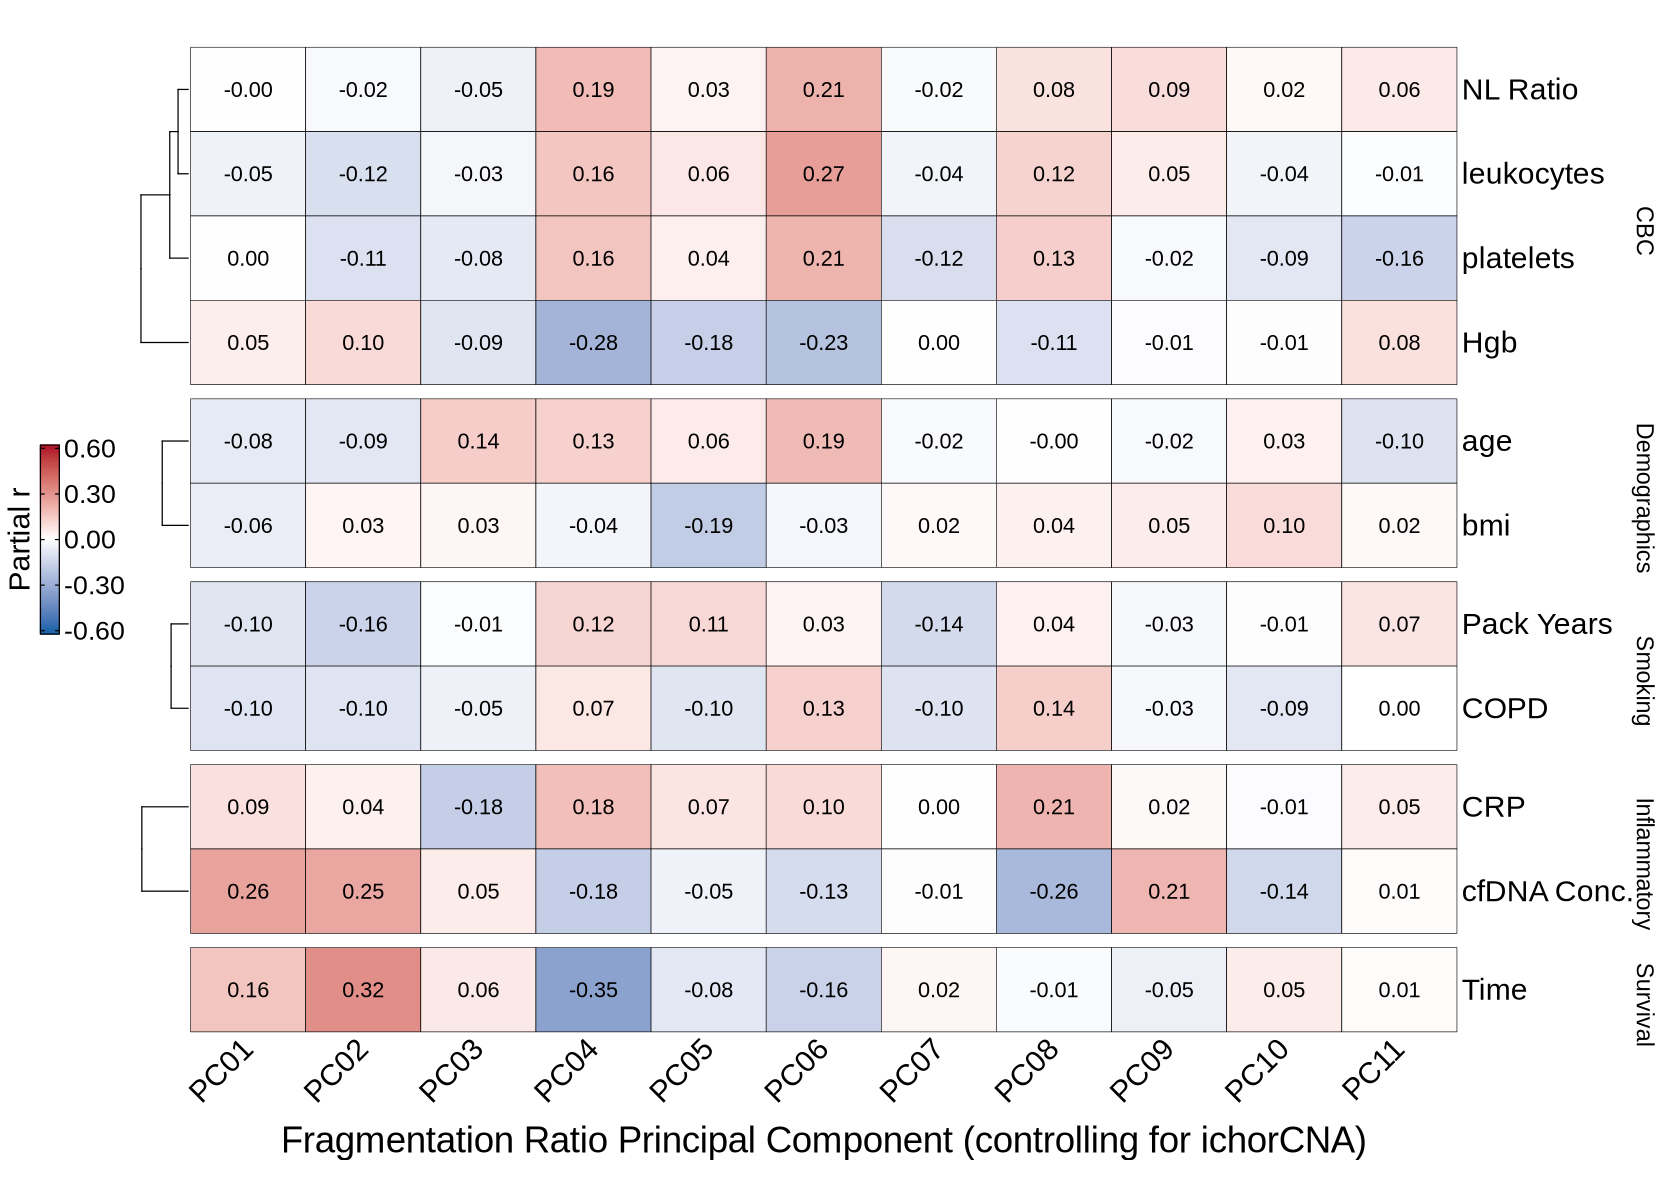

In [8]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(tidyr)
library(ppcor)

# Helper function for partial correlation
safe_pcor <- function(x, y, z) {
  tryCatch({
    data <- data.frame(x = x, y = y, z = z)
    data <- data[complete.cases(data), ]
    if (nrow(data) < 3) return(NA_real_)
    result <- pcor.test(data$x, data$y, data$z)
    return(result$estimate)
  }, error = function(e) {
    return(NA_real_)
  })
}

# Define clinical variables
clinical_vars <- c(
  "clinical_leukocytes", "clinical_nlratio",
  "clinical_Hgb", "clinical_platelets",
  "clinical_age", "clinical_sex", "clinical_bmi",
  "clinical_smokingstatus", "clinical_packyears", "clinical_COPD",
  "clinical_CRP", "clinical_cfdna_conc",
  "clinical_survival"
)

# Filter to existing numeric variables
clinical_vars <- clinical_vars[clinical_vars %in% names(lucas_df)]
clinical_vars <- clinical_vars[sapply(lucas_df[clinical_vars], is.numeric)]

# Get ratio_pc columns
ratio_cols <- names(lucas_df %>% dplyr::select(starts_with("ratio_pc")))

# Compute partial correlation matrix controlling for ichor
cor_mat <- matrix(NA, nrow = length(clinical_vars), ncol = length(ratio_cols))
rownames(cor_mat) <- clinical_vars
colnames(cor_mat) <- ratio_cols

for (i in seq_along(clinical_vars)) {
  for (j in seq_along(ratio_cols)) {
    cor_mat[i, j] <- safe_pcor(
      lucas_df[[clinical_vars[i]]],
      lucas_df[[ratio_cols[j]]],
      lucas_df$ichor
    )
  }
}

cor_mat[is.na(cor_mat)] <- 0

# Define row groupings
row_groups <- sapply(rownames(cor_mat), function(var) {
  if (grepl("Hgb|platelets|leukocytes|nlratio", var)) "01_CBC"
  else if (grepl("age|sex|bmi", var)) "02_Demographics"
  else if (grepl("smoking|packyears|COPD", var)) "03_Smoking"
  else if (grepl("CRP|cfdna", var)) "04_Inflammatory"
  else if (grepl("survival", var)) "05_Survival"
  else "06_Other"
})

# Order rows by group
row_order <- order(row_groups)
cor_mat <- cor_mat[row_order, ]
row_groups <- row_groups[row_order]

# Clean labels
rownames(cor_mat) <- gsub("^clinical_", "", rownames(cor_mat))
rownames(cor_mat) <- gsub("cfdna_conc", "cfDNA Conc.", rownames(cor_mat))
rownames(cor_mat) <- gsub("nlratio", "NL Ratio", rownames(cor_mat))
rownames(cor_mat) <- gsub("packyears", "Pack Years", rownames(cor_mat))
rownames(cor_mat) <- gsub("survival", "Time", rownames(cor_mat))
rownames(cor_mat) <- gsub("smokingstatus", "Smoking Status", rownames(cor_mat))
colnames(cor_mat) <- gsub("ratio_pc_", "PC", colnames(cor_mat))

# Color scale
cor_max <- 0.6
col_fun <- colorRamp2(c(-cor_max, 0, cor_max), c("#2166AC", "white", "#B2182B"))

# Row split factor
row_split <- factor(row_groups, levels = unique(row_groups))
clean_labels <- gsub("^[0-9]+_", "     ", levels(row_split))

# Create heatmap
ht <- Heatmap(
  cor_mat,
  name = "Partial Correlation",
  col = col_fun,

  cluster_rows = TRUE,
  cluster_row_slices = FALSE,
  cluster_columns = FALSE,
  show_column_dend = FALSE,

  row_split = row_split,
  row_gap = unit(3, "mm"),
  row_title = clean_labels,
  row_title_side = "right",
  row_title_rot = 270,
  row_title_gp = gpar(fontsize = 14),

  column_title = "Fragmentation Ratio Principal Component (controlling for ichorCNA)",
  column_title_side = "bottom",
  column_title_gp = gpar(fontsize = 22),

  row_names_side = "right",
  column_names_side = "bottom",
  row_names_gp = gpar(fontsize = 18),
  column_names_gp = gpar(fontsize = 18),
  column_names_rot = 45,

  rect_gp = gpar(col = "black", lwd = 0.5),

  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(sprintf("%.2f", cor_mat[i, j]), x, y, gp = gpar(fontsize = 13))
  },

  heatmap_legend_param = list(
    title = "Partial r",
    legend_direction = "vertical",
    title_position = "leftcenter-rot",
    at = seq(-cor_max, cor_max, length.out = 5),
    labels = sprintf("%.2f", seq(-cor_max, cor_max, length.out = 5)),
    border = "black",
    legend_height = unit(4, "cm"),
    labels_gp = gpar(fontsize = 16),
    title_gp = gpar(fontsize = 18)
  )
)

options(repr.plot.width = 14, repr.plot.height = 10)
draw(ht, heatmap_legend_side = "left", padding = unit(c(10, 2, 10, 2), "mm"))

In [9]:
png("../../outputs/Extended/Ext-Data-Fig-4-PC_clinical_heatmap_ichor_contr.png", width = 14, height = 10, units = "in", res = 300)
draw(ht, heatmap_legend_side = "left", padding = unit(c(10, 2, 10, 2), "mm"))
dev.off()

pdf 
  2

In [ ]:
## Done ##